Nesse modulo vai ser abordado o Projeto de predição de carro usando regressão linear.
Para treinar um modelo é preciso de um grande acervo de dados, existe um site chamado Kaggle.

1 -O plano sera pegar dados e analisar eles, compreender as informações;

2 -Preparar os dados e treinar o modelo de regressão linear e prever o MSRP(Valor sugerido do fabricante)

3 -Avaliar o modelo com RMSE( Raiz do erro quadratico médio) - Como se fosse um erro médio do modelo.
Quanto menor o RMSE melhor a avaliação. Um desvio medio entre o valor real e o previsto.

4 -Crias novas features para nosso modelo, novas caractéristicas que podemos usar.

5 -Lidar com alguns problemas de cálculos e como resolver com regularization.

6 - Usar o modelo.


In [1]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv')

# df.columns.str.lower().str.replace(' ', '_')
# assim substituimos nas colunas o espaço entre palavras para '_' e todas as letras minusculas
# isso para podermos fazer a associação de colunas sem erros por letra maiuscula
# e outro problema é quando possui uma letra com ' ' - espaço, existem várias funções que
# não funcionam devido ao espaço entre as palavras.
df.columns = df.columns.str.lower().str.replace(' ', '_')
# Também precisamos padronizar as informações nas linhas/rows onde seria nesse exemplo seria os carros.
df.dtypes
# vemos o tipo de dados que estão armazenados em cada coluna para transformar apenas as strings.
strings = list(df.dtypes[df.dtypes == 'string'].index)
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')
# Agora com colunas e informações padronizadas, podemos compreender mais as informações que temos
# Primeiramente verificar em cada coluna os itens unicos que temos em cada coluna.
for col in df.columns:
    # Primeiro exibimos para cada coluna o nome da coluna, as informações unicas quantas informações unicas possui.
    print(col)
    print(df[col].unique())
    print(df[col].nunique())
    print()

In [61]:
df.head()


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [24]:
# Matplotlib e Seaborn São duas bibliotecas que serão usados para visualização desse dados
# de uma forma com maior design.
import matplotlib.pyplot as plt
# Usado para representação de gráficos e estatísticas.
import seaborn as sns
# Uma biblioteca de alto nivel baseada no matplotlib usada para automatizar visualizações de estatísticas complexas
# com uma aparencia mais limpa e padronizada.
%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

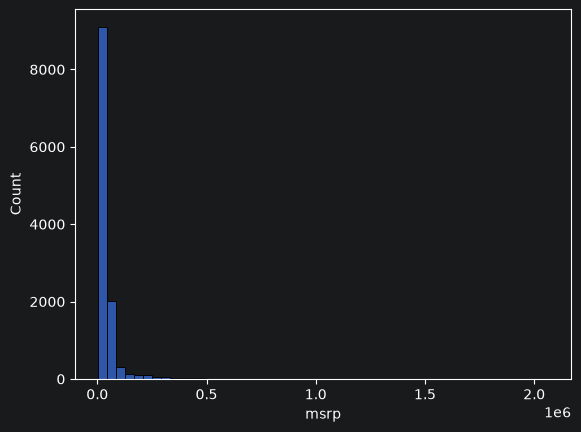

In [34]:
sns.histplot(df.msrp,bins=50) # bins sendo o tanto de barras que deseja visualizar

<Axes: xlabel='msrp', ylabel='Count'>

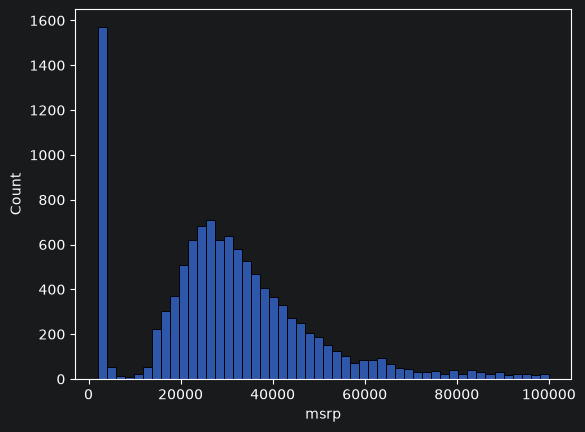

In [35]:
sns.histplot(df.msrp[df.msrp < 100000],bins=50) # Outra forma é usar filtros para vermos em escopo mais aproximado.

In [37]:
# Como vemos em no gráfico possui vários valores para um carro, sendo carros de luxo muito caros, e assim sendo em uma menor quantidade e valores estranhamente abaixo normal, esses valores desproporcionais podem afetas o modelo
# Aplicaremos um logaritmo nos valores com a função de numpy np.log1p() que alem de fazer o logaritmo adiciona +1 em todos os seus valores para não haver erro caso haja um 0 entre os numeros.
preco_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

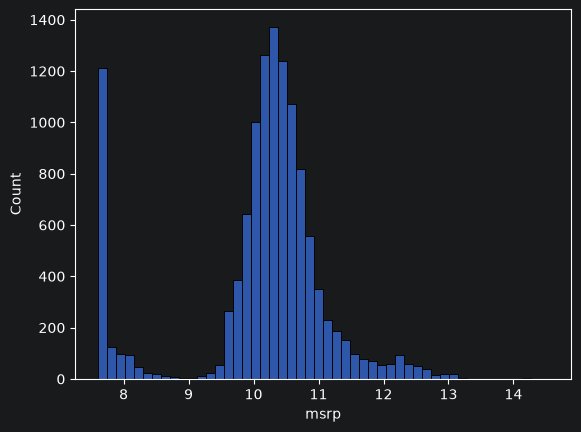

In [39]:
sns.histplot(preco_logs, bins=50)
# vemos que possui uma distribuição padrao no meio dos preços, a cauda de valores exorbitantes diminui junto com os valores estranhamente menores de 1000$ também diminui em relação ao padrao.
# esse pico de valor baixo pode ser analisado para ser compreendido.
# Mas geralmente uma distribuição padrao como essa é ideal para os modelos de predição

In [40]:
# Verificando os valores nulos com .isnull()-Retorna true para valor nulo e .sum() - ira somar quantos true tem em cada coluna.
df.isnull().sum()
# Temos que estar atentos a essa falta de informação quando for feito o treino do modelo.

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [62]:
# Criando o campo de validação do modelo:
# Com os dados que temos separamos entre dados de treino, de validação e de teste
# Separando-os em 3 matrizes e targets. Geralmente na proporção 60% 20% 20%.
n = len(df)
# Primeiro precisamos saber quantos linhas de dados temos para fazer essa divisão.

vali_n = int(n*0.2)
test_n = int(n*0.2)
train_n = n - vali_n - test_n
# Atribuindo uma variavel ao tanto de linhas que queremos separar.
# Agora que sabemos o tamanho que precisamos separar do data frame. Usando iloc que retorna a linha baseada em indexação. iloc(start,stop)
df_train = df.iloc[:train_n] #Sendo o resto do total.
df_vali = df.iloc[train_n:train_n + vali_n] #vali_n sendo 2382
df_test = df.iloc[train_n + vali_n:] # test_n sendo 2382,
# Precisamos randomizar as linhas dos dados, devido a estar por alguma ordem alfabetica ou modelo.
idx = np.arange(n) # n sendo todas as linhas

# Por aprendizado vai ser setado uma seed onde vai ser alterado randomicamente mas reproduzivel.
np.random.seed(2)
np.random.shuffle(idx)

df_train = df.iloc[idx[train_n:]]
df_vali = df.iloc[idx[train_n:train_n + vali_n]]
df_test = df.iloc[idx[train_n + vali_n:]]


In [63]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
2779,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
3708,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
4794,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
10498,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
1880,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
11798,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
6637,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
2575,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [64]:
# Como os numeros de index aparecem ao lado esquerdo de forma desordenada devido ao randomizar.
df_train = df_train.reset_index(drop=True)
df_vali = df_vali.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
# Assim formatamos a indexação dos nossos campos randomizados e separados.
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,chevrolet,colorado,2015,regular_unleaded,200.0,4.0,automatic,four_wheel_drive,4.0,NaN,compact,extended_cab_pickup,25,19,1385,26885
1,mercedes-benz,e-class,2017,premium_unleaded_(required),241.0,4.0,automatic,all_wheel_drive,4.0,luxury,midsize,sedan,29,22,617,54650
2,ford,focus,2017,flex-fuel_(unleaded/e85),160.0,4.0,manual,front_wheel_drive,4.0,flex_fuel,compact,sedan,36,26,5657,16775
3,acura,tlx,2016,premium_unleaded_(recommended),290.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,34,21,204,42600
4,volkswagen,beetle_convertible,2016,regular_unleaded,170.0,4.0,automatic,front_wheel_drive,2.0,NaN,compact,convertible,34,25,873,25995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4759,chevrolet,chevy_van,1998,regular_unleaded,200.0,6.0,automatic,rear_wheel_drive,3.0,NaN,midsize,cargo_van,18,13,1385,2052
4760,subaru,xv_crosstrek,2014,regular_unleaded,160.0,4.0,automatic,all_wheel_drive,4.0,"crossover,hybrid",compact,4dr_suv,33,29,640,25995
4761,dodge,magnum,2006,regular_unleaded,250.0,6.0,automatic,all_wheel_drive,4.0,NaN,large,wagon,22,15,1851,29100
4762,honda,civic,2016,regular_unleaded,174.0,4.0,automatic,front_wheel_drive,4.0,NaN,midsize,sedan,42,31,2202,22200


In [66]:
# Criando a variavel y a partir dos preços dos campos de validação usando logaritimo + 1.
y_train = np.log1p(df_train.msrp.values)
y_vali = np.log1p(df_vali.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [67]:
# Para prevermos o valor do preço, não podemos ter esse valor, se não o modelo iria ficar inviesado e talvez não fosse eficaz com novos valores da realidade.
# Então apagamos a coluna de preço
del df_train['msrp']
del df_vali['msrp']
del df_test['msrp']